# Tutorial Part 2: pixel-based phase mapping

Written by Jean-Baptiste Jacob

Last updated: 18/02/2025



The main issue with phase mapping in complex samples like polycrystalline rocks the overlap of scattering angles $2\theta$ between different phases. This can create ambiguities in peak-to-phase assignment when a peak can match multiple phases. In this second tutorial, we will see how to improve phase mapping using a pixel-based mapping approach. 

Here, we assume that the different crystallographic phases in our sample are already known and that we have their crystal structure files (CIF files). 

This may not be the case in general. Crystal structures from CIF files collected in online databases may have been measured at different P–T conditions or on crystals of slightly different composition, and therefore may not match perfectly with our data. It is also possible that some or all of the phases in the sample are unknown and need to be identified beforehand. 

A brief strategy for identifying or refining unknown crystal structures from 3DXRD data is described in the previous tutorial. Currently, there is no dedicated notebook for this task, but perhaps one will be developed in the future.


### Load packages

In [1]:
import sys

# python environment stuff
IMAGED11_PATH = '/home/esrf/jean1994b'  # None means do not use git, otherwise enter the name of the folder to use for the git checkout "ImageD11" or "ImageD11_version_xx", etc
CHECKOUT_PATH = 'ImageD11'  # the name of the git checkout folder within path. None means guess


if IMAGED11_PATH is not None:
    if '/data/id11/nanoscope' not in sys.path:
        sys.path.append('/data/id11/nanoscope')
    import install_ImageD11_from_git
    install_ImageD11_from_git.setup_ImageD11_from_git(IMAGED11_PATH,CHECKOUT_PATH)

# Setting path via: 
sys.path.insert(0, /home/esrf/jean1994b/ImageD11 )
# Running from: /home/esrf/jean1994b/ImageD11/ImageD11/__init__.py


In [1]:
# general modules
import os,  glob
import h5py
import matplotlib.pyplot as pl
import numpy as np
from concurrent.futures import ProcessPoolExecutor
import multiprocessing
from tqdm import tqdm

# ImageD11 https://github.com/FABLE-3DXRD/ImageD11
import ImageD11.sinograms.dataset
import ImageD11.columnfile
import ImageD11.parameters

# point-fit 3dxrd module available at https://github.com/jbjacob94/pf_3dxrd.
# Not yet installable with pip, just copy + paste the files into your working folder   
from pf3dxrd.pf3dxrd import utils, friedel_pairs, pixelmap, crystal_structure, peak_mapping, phase_mapping

%load_ext autoreload
%autoreload 2
%matplotlib ipympl

### Load data & crystal structures

First we need to load the peakfile with paired peaks, that we previously computed in the first tutorial. This file should end with *_pks_p.h5. If not just modify the path in the loading function.

In [2]:
def load_data(dsname, parfile):
    
    # paths
    pksfile = os.path.join(data_dir, dsname+'_pk2d_p.h5')
    dsfile  = os.path.join(data_dir, dsname+'_dataset.h5')
    
    # load ds file and peak file
    ds = ImageD11.sinograms.dataset.load(dsfile)
    print(f'Loading data for dataset {ds.dsname}: \n==============================')    
    items = 'n_ystep,n_ostep,ymin,ymax,ystep,omin,omax,ostep'.split(',')
    vals  = [ds.shape[0], ds.shape[1], ds.ymin, ds.ymax, ds.ystep, ds.omin, ds.omax, ds.ostep]
    for i,j in zip(items, vals):
        print(f'{i}: {j:.2f}')
        
    print('==============================')
    
    
    cf = ImageD11.columnfile.columnfile(pksfile)
    cf.parameters.loadparameters(parfile)
    
    # update tth, etc. using Friedel pairs.
    if not cf.sortedby == 'fp_id':
        cf.sortby('fp_id')
    friedel_pairs.update_geometry_fpairs(cf, ds)
    
    print('\n loaded peakfile: \nnrows =', cf.nrows)
    utils.get_colf_size(cf)
    
    return cf, ds


In [3]:
# paths
data_dir = '/home/esrf/jean1994b/test_datasets/SI3/'
#data_dir = '/home/esrf/jean1994b/test_datasets/C18A_01_z180/'

dsname = 'SI3_DT360Z5480'
#dsname = 'C18A_01_z180'
parfile= data_dir+'SI3.par'
#parfile = data_dir+'C18A_01.par'

In [4]:
# load data
cf, ds = load_data(dsname, parfile)

Loading data for dataset SI3_DT360Z5480: 
n_ystep: 109.00
n_ostep: 450.00
ymin: -2.70
ymax: 2.70
ystep: 0.05
omin: 0.00
omax: 360.00
ostep: 0.80
Reading your columnfile in hdf format


copied an array: size=3125506, elsize=4
copied an array: size=3125506, elsize=4
copied an array: size=3125506, elsize=4
copied an array: size=3125506, elsize=4



 loaded peakfile: 
nrows = 3125506
Total size =  202.69 MB


We need to load crystal structures as well. We will use the CS class from crystal_structure.py introduced in the previous tutorial.

In [137]:
# load crystal structures and store them in a dictionnary
pnames = ['quartz', 'magnetite', 'biotite', 'orthoclase', 'oligoclase'] # cif files should be named '<phase_name>.cif'
#pnames = ['quartz', 'garnet'] # 
phase_dict = {name: crystal_structure.load_CS_from_cif(cif_path = f'cif/{name}.cif', name=name, pid = i) for i,name in enumerate(pnames)}

for cs in phase_dict.values():
    print(cs)


CS: quartz, phase_id: 0, spg: P3221, spg_no: 154, lattice: [  4.91325   4.91325   5.41206  90.       90.      120.     ]
CS: magnetite, phase_id: 1, spg: Fd3m, spg_no: 227, lattice: [ 8.3965  8.3965  8.3965 90.     90.     90.    ]
CS: biotite, phase_id: 2, spg: C12/m1, spg_no: 12, lattice: [  5.355   9.251  10.246  90.    100.15   90.   ]
CS: orthoclase, phase_id: 3, spg: C1-11, spg_no: 12, lattice: [  8.589  13.013   7.197  90.    116.02   90.   ]
CS: oligoclase, phase_id: 4, spg: C-1, spg_no: 2, lattice: [  8.154  12.823   7.139  94.06  116.5    88.59 ]


### Create a 2D pixel grid with Pixelmap

Phase mapping is performed on a 2D grid of pixels, where the size of the grid is determined by the scanning range along the y-axis and the resolution is given by the y-step size. To make this process more convenient, a new class, `Pixelmap`, is introduced from the module `pixelmap.py`. It creates a "pixelmap" (`xmap`) object, which allows mapping properties onto a fixed 2D grid. 

This class offers many functionalities, which we will explore in this tutorial and the following ones. From now on, it will be the main object we work with, alongside `ImageD11` column files.  

First, we need to initialize the pixelmap. To do this, we must define a grid.


In [138]:
# Initialize pixelmap grid
xb = yb = np.arange(len(ds.ybinedges)) # bins
xmap = pixelmap.Pixelmap(xb, yb, h5name = os.path.join(data_dir, ds.dsname+'_xmap.h5'))

if 'frelon' in ds.detector:
    xmap.grid.pixel_size = ds.ystep * 1000   # with the frelon detector ystep is given in mm; convert it to µm
else:
    xmap.grid.pixel_size = ds.ystep
    
xmap.grid.pixel_unit = 'µm'

print(xmap)
print(xmap.grid)

for t in xmap.titles():
    print(t, xmap.get(t).shape)

Pixelmap:
 size: (110, 110),
 phases: ['notIndexed'],
 phase_ids: [-1],
 titles: ['xyi', 'xi', 'yi', 'phase_id', 'grain_id'], 
 grains: 0
grid: size: (110, 110), pixel size: 50.00 µm
xyi (12100,)
xi (12100,)
yi (12100,)
phase_id (12100,)
grain_id (12100,)


The map contains a stack of data arrays, as well as several sub-classes to store information on the grid, grains, and the crystal structure of each phase. Specifically, the `Pixelmap` contains sub-class objects `phases`, `grid`, and `grains`, which store information on crystal structures, the pixel grid, and indexed grains, respectively.

e.g. in dataset `SI3DT360Z5480`, the map is defined on a 110×110 pixel grid (i.e., 12,100 pixels), with a pixel size of 50 µm. Data columns are `ndarray`s of shape `(N, M)`, where `N = nx × ny`. Some columns are defined during initialization, namely `xi`, `yi`, `xyi`, `phase_id`, and `grain_id`. Let's have a look.


In [139]:
# have a look on a subset of xi, yi and xyi arrays
for t in ['xi','yi','xyi']:
    print(f'{t} : {xmap.get(t)[120:130:2]}')

# xi and yi can be easily retrived from xyi:
print(f'xyi%10000:{xmap.xyi[120:130:2]%10000}')
print(f'xyi//10000:{xmap.xyi[120:130:2]//10000}')

xi : [10 12 14 16 18]
yi : [1 1 1 1 1]
xyi : [10010 10012 10014 10016 10018]
xyi%10000:[10 12 14 16 18]
xyi//10000:[1 1 1 1 1]


`xi` and `yi` correspond to the pixel positions along the x and y axes, respectively. `xyi` is a unique index built from these two coordinates: 

$$xyi = xi + 10000 \cdot yi$$

This index is unique for each pixel as long as the map is less than 10,000 pixels wide, which is normally the case. It allows for rapid searching of pixels by index in a single list, rather than using two separate lists, while preserving the pixel coordinate information.

`phase_id` and `grain_id` are arrays of index values that relate each pixel on the map to a specific phase or grain. Since no indexing has been performed yet, these arrays currently contain only `-1` values.



In [140]:
print(f'{xmap.phase_id=:} {xmap.phase_id.shape:}')
print(f'{xmap.grain_id=:} {xmap.grain_id.shape:}')

xmap.phase_id=[-1 -1 -1 ... -1 -1 -1] (12100,)
xmap.grain_id=[-1 -1 -1 ... -1 -1 -1] (12100,)


It is also possible to initialize xmap directly from a dataset object

In [141]:
xmap = pixelmap.create_from_dataset(ds, h5name = os.path.join(data_dir, ds.dsname+'_xmap.h5') )
print(xmap)

Pixelmap:
 size: (110, 110),
 phases: ['notIndexed'],
 phase_ids: [-1],
 titles: ['xyi', 'xi', 'yi', 'phase_id', 'grain_id'], 
 grains: 0


**NOTE:** The `Pixelmap` class is quite similar to `TensorMap` in ImageD11 and aims at doing the same thing: storing scanning-3DXRD maps of strain, orientation, or any other property derived from scanning-3DXRD measurements that cna be mapped on a 2D grid. However, it is structured slightly differently. It can only handle single s3DXRD slice (no 3D volume) but has additional functionalities, especially for grain mapping grain boundaries or grain orientation refinement). The full pf3dxrd pipeline depends on `Pixelmap`, so switching to `TensorMap` for processing might be a bit tedious. 
Hopefully, Conversion from Pixelmap to TensorMap is quite straightforward using a built-in method

In [142]:
from ImageD11.sinograms import tensor_map
tmap = xmap.to_tensor_map()
print(tmap)

So far, only the grid has been initialized. Now, let's add phases.

In [143]:
# Add phases from phase_dict
for phasename, cs in phase_dict.items():
    xmap.phases.add_phase(phasename, cs)
    
# print some information about pixelmap
print(xmap,'\n-------')
print(xmap.grid,'\n-------')
print(xmap.phases)

for p in xmap.phases.pnames: 
    print(xmap.phases.get(p))

Pixelmap:
 size: (110, 110),
 phases: ['notIndexed', 'quartz', 'magnetite', 'biotite', 'orthoclase', 'oligoclase'],
 phase_ids: [-1, 0, 1, 2, 3, 4],
 titles: ['xyi', 'xi', 'yi', 'phase_id', 'grain_id'], 
 grains: 0 
-------
grid: size: (110, 110), pixel size: 50.00 µm 
-------
phases: ['notIndexed', 'quartz', 'magnetite', 'biotite', 'orthoclase', 'oligoclase']
CS: notIndexed, phase_id: -1, spg: None, spg_no: None, lattice: []
CS: quartz, phase_id: 0, spg: P3221, spg_no: 154, lattice: [  4.91325   4.91325   5.41206  90.       90.      120.     ]
CS: magnetite, phase_id: 1, spg: Fd3m, spg_no: 227, lattice: [ 8.3965  8.3965  8.3965 90.     90.     90.    ]
CS: biotite, phase_id: 2, spg: C12/m1, spg_no: 12, lattice: [  5.355   9.251  10.246  90.    100.15   90.   ]
CS: orthoclase, phase_id: 3, spg: C1-11, spg_no: 12, lattice: [  8.589  13.013   7.197  90.    116.02   90.   ]
CS: oligoclase, phase_id: 4, spg: C-1, spg_no: 2, lattice: [  8.154  12.823   7.139  94.06  116.5    88.59 ]


For each phase, a `CS` object is attached and can be accessed via `xmap.phases.phase_name` or by using the method `xmap.phases.get('phase_name')`.  
The list of all phase names and phase indices is available in `xmap.phases.pnames` and `xmap.phases.pids`, respectively.


In [144]:
xmap.phases.pnames, xmap.phases.pids

(['notIndexed', 'quartz', 'magnetite', 'biotite', 'orthoclase', 'oligoclase'],
 [-1, 0, 1, 2, 3, 4])

### Map phases pixel-by-pixel with `PhaseMapper`

Now we have a peakfile `cf` containing peaks, a list of crystal phases in `phase_dict`, and a 2D map `xmap` on which the phases will be mapped. Our goal is to use the diffraction peaks in the peakfile to find the best-matching phase (among the list provided) for each pixel of the map. This is done using the class `PhaseMapper` from `phase_mapping.py`.

First, we need to initialize a new `PhaseMapper` object using our columnfile, pixelmap, and list of crystal structures.

In [145]:
# PhaseMapper object to map peaks to pixel and find best phase match on the 2D grid
PhaseMapper = phase_mapping.PhaseMapper(cf, ds, xmap, CS_list=phase_dict.values())

print('================= \n',PhaseMapper)

 PhaseMapper
-----------
Peaks to map      : 2148612
Number of phases : 5
Phase names      : [quartz, magnetite, biotite, orthoclase, oligoclase]
Phase IDs        : [0, 1, 2, 3, 4]
Pixel grid       : grid: size: (110, 110), pixel size: 50.00 µm
minpks           : 50
min_confidence   : 0.100
kernel_size      : 1



In [146]:
# NB: since we already added phases to xmap, it is possible to pass these directly to PhaseMapper
PhaseMapper = phase_mapping.PhaseMapper(cf, ds, xmap)
PhaseMapper.add_phases_from_pixelmap()

print('================= \n',PhaseMapper)

 PhaseMapper
-----------
Peaks to map      : 2148612
Number of phases : 5
Phase names      : [quartz, magnetite, biotite, orthoclase, oligoclase]
Phase IDs        : [0, 1, 2, 3, 4]
Pixel grid       : grid: size: (110, 110), pixel size: 50.00 µm
minpks           : 50
min_confidence   : 0.100
kernel_size      : 1



#### Phase labeling strategy

Phase labeling involves assigning a phase label (corresponding to one of the pre-selected crystal structures in the list) to each peak in the peakfile and to each pixel on the 2D map. The strategy consists of two main steps:

1. **Peak selection with Boolean masks:**  
   Boolean selection masks are computed for each phase, selecting peaks based on a 2-theta threshold around each theoretical Bragg peak of that phase. For example, if a phase has Bragg peaks at $2\theta$ angles 3°, 5°, and 8° and a $2\theta$ threshold of 0.1° is used, all peaks within the ranges [2.9–3.1], [4.9–5.1], and [7.9–8.1] will be selected. At this stage, overlaps can occur, and a peak may be assigned to multiple selection masks of different phases if it lies within an interval where multiple phase masks overlap.

2. **Pixel-by-pixel phase assignment:**  
   For each pixel, all peaks arising from that pixel are selected. Using the pre-computed phase selection masks, the best-matching phase is determined for the pixel, and completeness and uniqueness criteria are computed to evaluate the quality of the phase match. If the match exceeds a certain threshold, a phase label is assigned to the pixel and to the peaks arising from it. Performing this assignment at the pixel level allows much better handling of overlap conflicts than simple 2-theta threshold selections.


#### Raw phase masks

First, we need to compute the $2\theta$ masks for each phase. Since we do not yet have the positions of the theoretical Bragg peaks for each phase, we need to compute them. This is done using the method `find_strongest_bragg_peaks` below, illustrated here with quartz.

The method takes a crystal structure as input and simulates the diffraction spectrum over a given 2-theta range. A peak search is then performed using `scipy.signal` to find the strongest peaks in this spectrum. The resulting list of peak positions and their corresponding intensities are added to `phasemapper.phases.[phasename]`.

`Imin` and `prominence` are parameters used in the peak search to determine which local maxima are considered peaks; see the `scipy.signal` documentation for more details. `Nmax` specifies the maximum number of peaks returned. The outputs from the peak search are sorted by decreasing intensity, and the N strongest peaks are retained.


Scatter(quartz with 2 atomic positions, 6 symmetries)
       Type: x-ray
     Energy: 43.57356018082551 keV
 Wavelength: 0.28454050670689945 A
 ---Settings---
      Powder units: tth
    Isotropic ADPs: True
  Specular Direction (reflection): ( 0, 0, 1)
Parallel Direction (transmission): ( 0, 0, 1)
      theta offset: 0.0
         min theta: -180.0
         max theta: 180.0
      min twotheta: 0
      max twotheta: 15
 ---X-Ray Settings---
 Waasmaier scattering factor: False
 ---Neutron Settings---
 Sears (ITC) scattering lengths: False
 ---Magnetic Settings---
   Mag. scattering: True
  Mag. form factor: True
         Polarised: False
      Polarisation: sp
       Pol. vector: (0,1,0)
 ---Resonant Settings---
   Azimuthal angle: 0
    Azimuthal ref.: (1,0,0)
               flm: (0,1,0)
  use e1e1 approx.: True



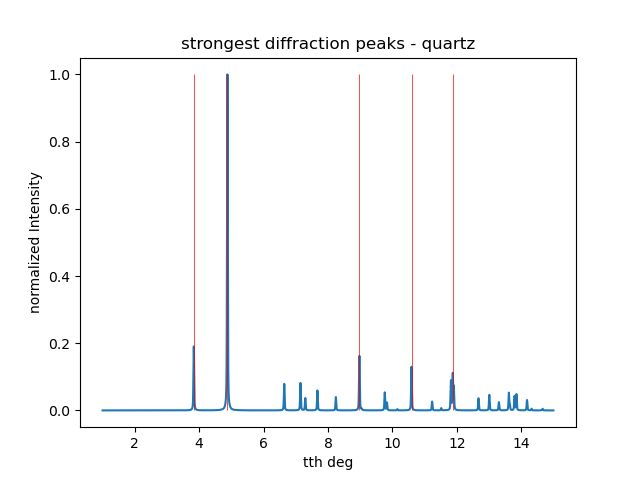

In [147]:
PhaseMapper.find_strongest_bragg_peaks('quartz', min_tth=0, max_tth=15, Nmax=40, Imin=0.1, prominence=0.1, doplot=True)

Here, `Imin` and `prominence` thresholds for the peak search were set quite high, so only a few peaks have been selected. These values can be lowered if more peaks are desired.
It is also possible to compute spectra and return Bragg peaks for all phases in `PhaseMapper` at once, using the method shown below.


In [ ]:
PhaseMapper.find_strongest_bragg_peaks_all(0, 15, Nmax=100, Imin=0.005, prominence=0.005, doplot=True) 

Now that the theoretical Bragg peaks have been computed, we can compute the phase selection masks using the method below.  

- `tthmax` specifies the maximum 2-theta value to consider (cuts off the largest scattering angles).  
- `tth_tol` defines the size of the threshold (in degrees) around each Bragg peak.  

The method returns the proportion of peaks selected in each mask, the total fraction of peaks assigned (i.e., selected by at least one phase), and the fraction of peak overlaps (peaks assigned to more than one phase).

Increasing the threshold will increase the proportion of selected peaks, but it will also increase the overlap, which is undesirable. The number of theoretical Bragg peaks retained (see above) also matters, especially for complex samples containing multiple phases with many theoretical peaks. If overlaps are too large, reducing `Nmax` or increasing `Imin` and `prominence` in the peak search may help.


**SI3_DT360Z5480**: quartz and magnetite have higher symmetry than other minerals in this sample, and therefore display much fewer distinct peaks in their diffraction spectrum. Phase labeling works better if different peak search thresholds are used

Scatter(quartz with 2 atomic positions, 6 symmetries)
       Type: x-ray
     Energy: 43.57356018082551 keV
 Wavelength: 0.28454050670689945 A
 ---Settings---
      Powder units: tth
    Isotropic ADPs: True
  Specular Direction (reflection): ( 0, 0, 1)
Parallel Direction (transmission): ( 0, 0, 1)
      theta offset: 0.0
         min theta: -180.0
         max theta: 180.0
      min twotheta: 0
      max twotheta: 15
 ---X-Ray Settings---
 Waasmaier scattering factor: False
 ---Neutron Settings---
 Sears (ITC) scattering lengths: False
 ---Magnetic Settings---
   Mag. scattering: True
  Mag. form factor: True
         Polarised: False
      Polarisation: sp
       Pol. vector: (0,1,0)
 ---Resonant Settings---
   Azimuthal angle: 0
    Azimuthal ref.: (1,0,0)
               flm: (0,1,0)
  use e1e1 approx.: True

Scatter(magnetite with 3 atomic positions, 192 symmetries)
       Type: x-ray
     Energy: 43.57356018082551 keV
 Wavelength: 0.28454050670689945 A
 ---Settings---
      Powder

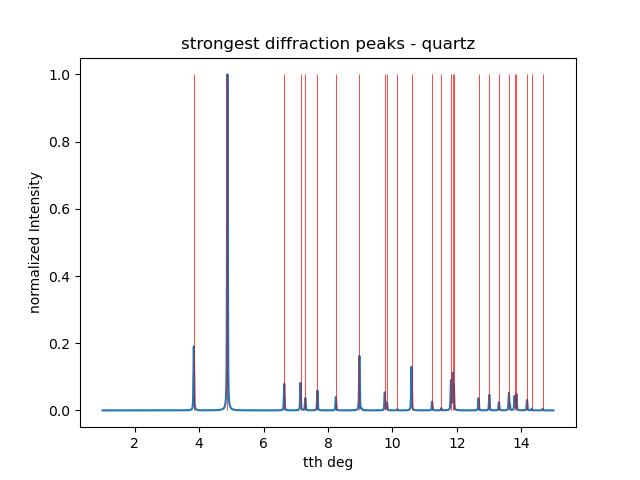

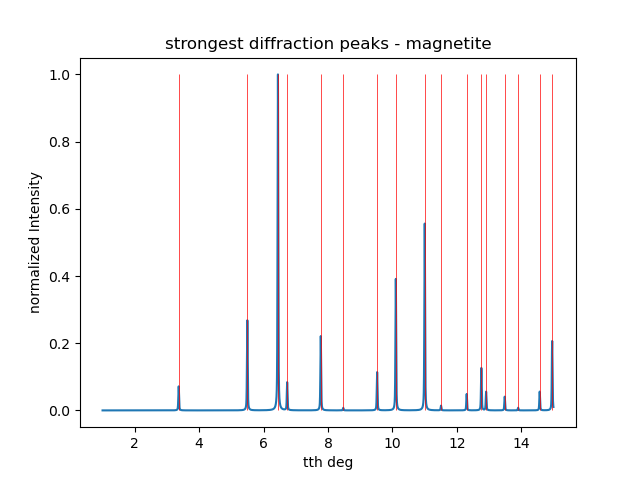

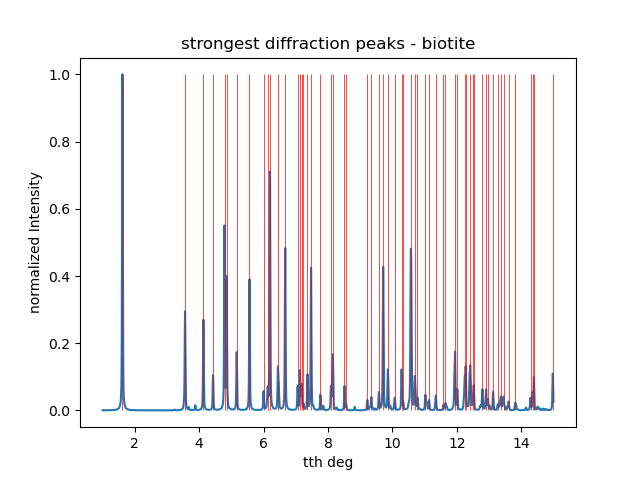

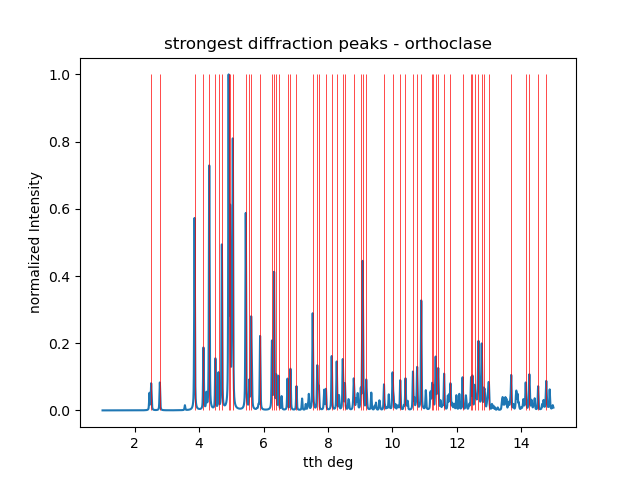

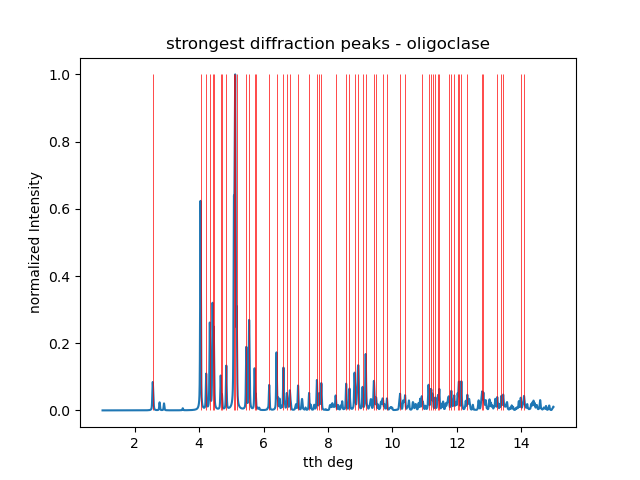

In [149]:
# for granite samples (SI3)
for phase in phase_dict.keys():
    if any([phase == 'oligoclase', phase == 'orthoclase', phase == 'biotite']):
         PhaseMapper.find_strongest_bragg_peaks(phase, 0,15, Nmax=60, Imin=0.005, prominence=0.005, doplot=True)
    else:
        PhaseMapper.find_strongest_bragg_peaks(phase, 0,15, Nmax=80, Imin=0.001, prominence=0.001, doplot=True)

In [150]:
# compute phase masks
PhaseMapper.compute_phase_mask_all(tth_max=15, tth_tol=0.03)

pks fraction quartz: 0.1543
pks fraction magnetite: 0.0249
pks fraction biotite: 0.1425
pks fraction orthoclase: 0.1840
pks fraction oligoclase: 0.3604

Total pks fraction assigned: 0.6373
fraction overlapping: 0.2146


It is usually a good idea to plot peaks in a $2\theta$ vs. $\eta$ diagram to verify that peaks from most of the main $2\theta$ rings have been selected and to identify where overlaps occur.  
`PhaseMapper` provides a method for plotting, where peaks are colored according to their phase masks.


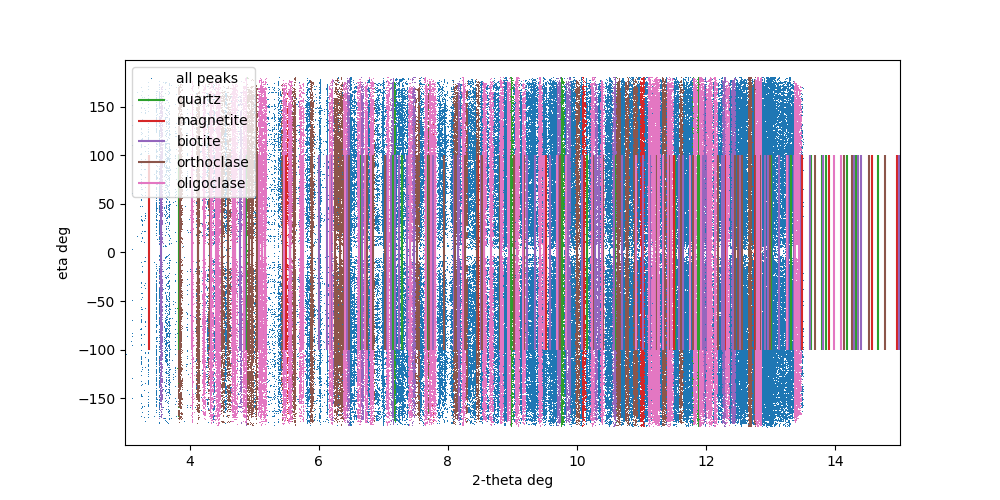

In [151]:
# plot tth vs eta for a subset of peaks to see what the selection looks like
PhaseMapper.plot_tth_eta(min_tth=3, max_tth=15, show_theorytth=True, phase_colors='from_mask')

Scatter plots can be quite messy. Plotting a $2\theta$ histogram sometimes look a bit more clear

/home/esrf/jean1994b/pf3dxrd/pf3dxrd/phase_mapping.py:455: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig = pl.figure(figsize=(10,5))


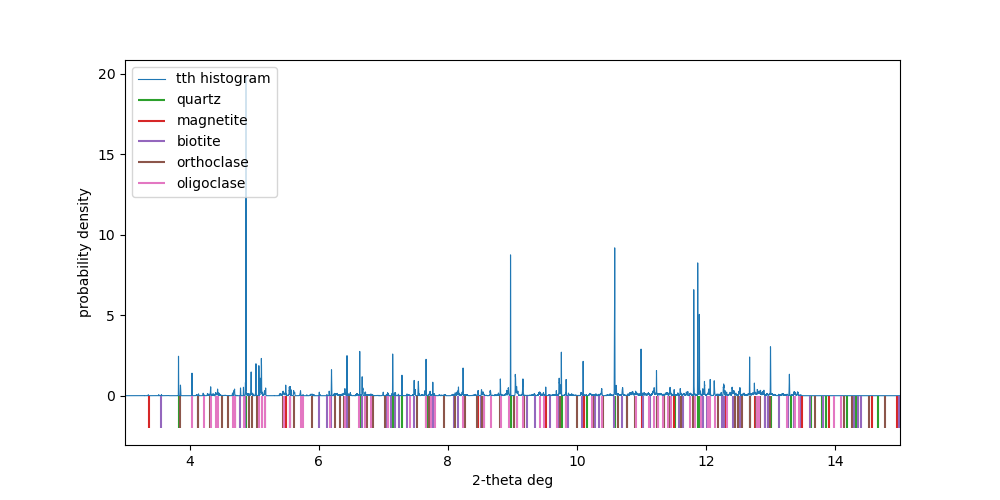

In [152]:
PhaseMapper.plot_tth_histogram(min_tth=3, max_tth=15, tth_step=0.0005, show_theorytth=True)

#### Prepare `PhaseMapper`

Now that the pre-selection phase masks have been added, several setup steps are required in `PhaseMapper` to prepare for phase labeling.  
This includes initializing the peakfile and sorting by `xyi` index. These steps are performed using the function below:


In [153]:
PhaseMapper.get_ready_for_phase_labeling()

preliminary check...
sorting peakfile by xyi...
Ready for phase labeling!


We also need to set up a few input parameters in `PhaseMapper`:

- **minpks**         : Minimum number of peaks on a pixel; below this, the pixel will remain unlabeled.  
- **min_confidence** : Lower threshold for the normalized confidence index; below this, the pixel will remain unlabeled.  
- **kernel_size**    : Peak selection is performed in an $n \times n$ selection window around each pixel. The default is $n=1$ (single-pixel selection), but the kernel size can be increased to produce a smoother map. If a larger kernel size is used, consider increasing `minpks` accordingly.  
- **chunksize**      :  determines how tasks are divided among processes in ProcessPoolExecutor. If chunksize = 100, 100 pixels will be processed by each worker at a time. 
- **ncpu**           : Number of CPUs used for multiprocessing. Default is the maximum number available.  
- **res**            : Dictionary in which phase labeling outputs are temporarily written.  

To choose a value for `minpks`, it is useful to examine the total number of peaks per pixel. By plotting the distribution, we can decide on a reasonable threshold. For instance, in dataset `SI3_DT360Z5480`, there are two populations of pixels: one with <200 peaks and another with >200 peaks. The pixels with a low peak count likely correspond to regions outside the sample, containing unreliable Friedel pairs for which peak relocalization is inaccurate. A `minpks` cutoff of 200 seems reasonable.  

However, since only a fraction of peaks per pixel will be selected by each phase, we reduce this value slightly to avoid being too restrictive. Here, we will start with `minpks = 100`.


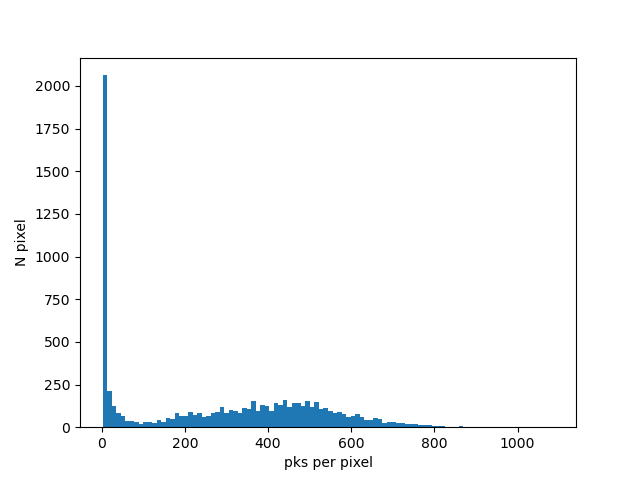

In [154]:
# plot the distribution of peak counts per pixel, to adjust the minpks parameter (below).
def npks_per_pixel_hist(cf):
    px, cnts = np.unique(cf.xyi, return_counts=True)
    pl.figure()
    pl.hist(cnts[cnts>0],100);
    pl.xlabel('pks per pixel')
    pl.ylabel('N pixel')
    
npks_per_pixel_hist(cf)

In [179]:
PhaseMapper.kernel_size = 1
PhaseMapper.minpks = 100
PhaseMapper.min_confidence = 0.05
PhaseMapper.chunksize = 500
PhaseMapper.res = {}

print(PhaseMapper)

PhaseMapper
-----------
Peaks to map      : 2148612
Number of phases : 5
Phase names      : [quartz, magnetite, biotite, orthoclase, oligoclase]
Phase IDs        : [0, 1, 2, 3, 4]
Pixel grid       : grid: size: (110, 110), pixel size: 50.00 µm
minpks           : 100
min_confidence   : 0.050
kernel_size      : 1



#### Phase labeling
This is done using the `label_phase` method. For each pixel (specified by its `xyi` index), it finds the best-matching phase and returns a tuple containing the following elements:

- **Phase ID**  
- **Confidence evaluation criteria**: completeness, uniqueness, and normalized confidence index  
- **List of peak indices**: peaks that should be updated with this phase label in the peakfile

The process can be run either sequentially or in parallel. in the latter case, PhaseMapper.ncpu controls the numnber of workers

In [180]:
PhaseMapper.label_phase(parallelize=True)

Mapping phases (parallel, fork): 100%|██████████| 7655/7655 [00:00<00:00, 42564.69it/s]


Results have been written in a dictionnary (PhaseMapper.res). Now we want to unpack these results, to add phase labels to the peakfile and to xmap

In [181]:
# write outputs in pixelmap. peakfile phase_id column is also updated at the same time, giving a phase label to each peak
PhaseMapper.results_to_xmap()

100%|██████████| 7655/7655 [00:00<00:00, 949810.59it/s]

Pixelmap:
 size: (110, 110),
 phases: ['notIndexed', 'quartz', 'magnetite', 'biotite', 'orthoclase', 'oligoclase'],
 phase_ids: [-1, 0, 1, 2, 3, 4],
 titles: ['xyi', 'xi', 'yi', 'phase_id', 'grain_id', 'Npks', 'phase_label_confidence', 'completeness', 'uniqueness'], 
 grains: 0


We can see that new columns have been added for the confidence criteria `phase_label_confidence`, `completeness`, `uniqueness` and the number of peaks `Npks`.  
Additionally, `phase_id` now contains more values, both in the `pixelmap` and in the peakfile.


In [182]:
print(np.unique(PhaseMapper.pixelmap.phase_id))
print(np.unique(PhaseMapper.peakfile.phase_id))

[-1  0  1  2  3  4]
[-1  0  1  2  3  4]


We can print some statistics about peak labeling

In [183]:
# print some stats about laleled peaks: fraction of peaks assigned to each phase (in proportion of the total number of peaks in peakfile)
PhaseMapper.get_stats_labeled_peaks()

fraction of labeled peaks 
----------
quartz: 0.0611
magnetite: 0.0015
biotite: 0.0318
orthoclase: 0.0435
oligoclase: 0.1845
assigned: 0.3224
fraction of total intensity 
----------
quartz: 0.1386
magnetite: 0.0134
biotite: 0.0853
orthoclase: 0.0641
oligoclase: 0.2107
assigned: 0.5121


We can also compare to the stats in the pre-computed masks. We see that overall, the proportion of peaks assigned to each phase has decreased, because  each overlapping peak had to "choose" one single phase. Also, peaks belonging to weak or unreliable pixels (npks < minpks or conf_ind < min_confidence) have been rejected, reducing overall the proportion of "assigned" peaks. 

In [184]:
PhaseMapper.get_stats_raw_masks()

peak fractions in raw selection masks 
----------
quartz: 0.1543
magnetite: 0.0249
biotite: 0.1425
orthoclase: 0.1840
oligoclase: 0.3604
overlap: 0.2146
assigned: 0.6373
fraction of total intensity in masks 
----------
quartz: 0.2941
magnetite: 0.0367
biotite: 0.2508
orthoclase: 0.1973
oligoclase: 0.3902
overlap: 0.3400
assigned: 0.8027


### Plots

`phase_id` and other properties have been added to the `pixelmap`. Now we can plot 2D maps for each property:

- **completeness**: Evaluates the proportion of total intensity matched for each pixel by the best-matching phase. It varies between 0 (no intensity matched) and 1 (100% intensity matched).  
- **uniqueness**: Evaluates how unique the phase match is. It varies between 0 (100% overlap with other phases) and 1 (0% overlap).  
- **phase_label_confidence**: A criterion between 0 and 1 built using the two quantities above.  
- **Npks**: Number of peaks matched on each pixel.  
- **phase_id**: Label identifying each phase. It corresponds to the `phase_id` defined in `xmap.phases.[phasename].phase_id`.


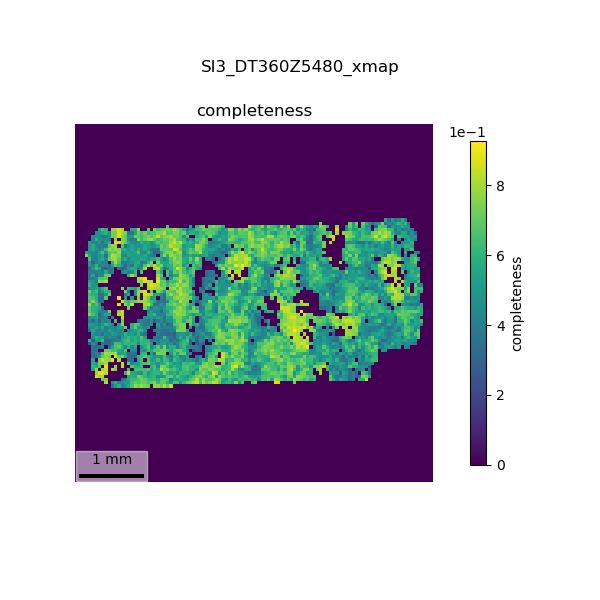

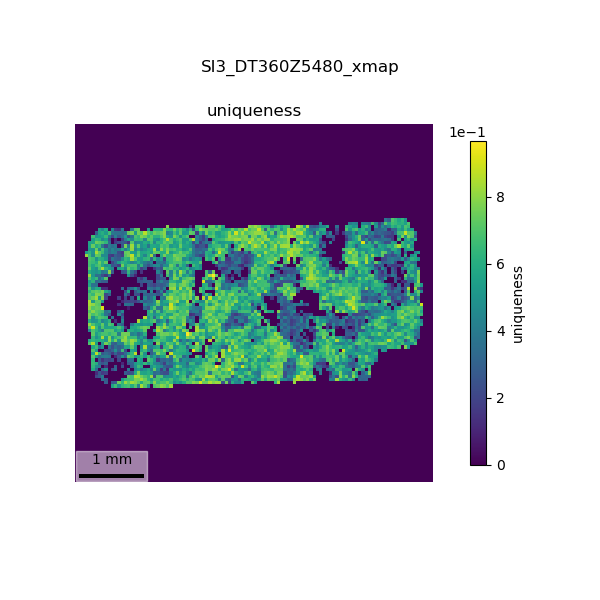

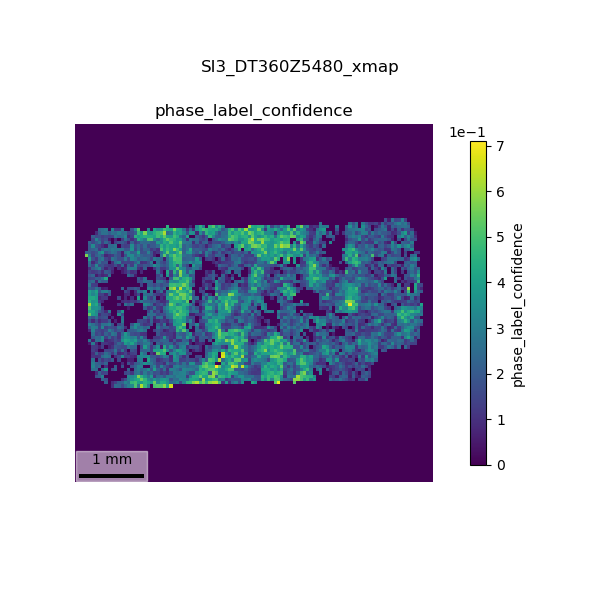

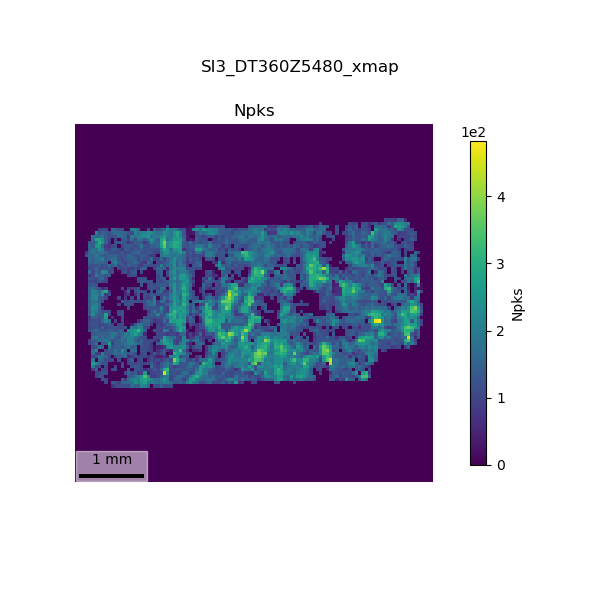

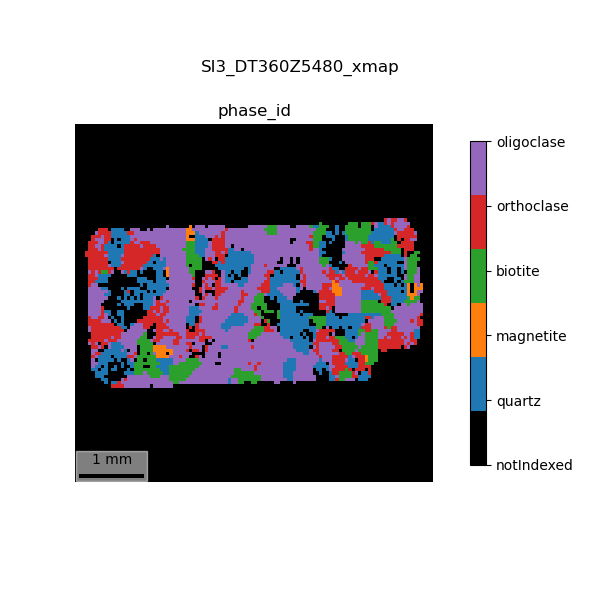

In [185]:
# make some plots and save : phase_id, Ci, Npks. 
pl.close('all')

colors = ((0,0,0),) + pl.matplotlib.cm.tab10.colors
cmap = pl.matplotlib.colors.ListedColormap( colors[:len(xmap.phases.pnames)] )

save=False
var_to_plot = ['completeness','uniqueness','phase_label_confidence','Npks','phase_id']

# use xmap plot function and loop through variables to plot. 
for i, var in enumerate(var_to_plot):
    if var == 'phase_id':
        kw = {'cmap':cmap}
        xmap.plot(var, autoscale=False, save=save, **kw)  
        
    else:
        kw = {'cmap':'viridis'}
        xmap.plot(var, autoscale=False, hist_tails_cut=[1, 99], save=save, **kw)


Now you can experiment with different parameters in `PhaseMapper` and re-run the phase mapping.

Try the following adjustments:

- **Increase `kernel_size` to 3** — don’t forget to increase `minpks` as well, since a larger kernel will naturally include more peaks. This should result in smoother maps.  
- **Increase `min_confidence`** — this will clean up the map by removing unreliable domains.  
- **Recompute phase masks** using a larger or smaller $2\theta$ threshold. You can also recompute theoretical Bragg peaks to retain more or fewer of them, and adjust the minimum `prominence` and `Imin` values accordingly.  

For more complex cases, you may need to define the  $2\theta$ thresholds and Bragg peak parameters (`Nmax`, `Imin`, `prominence`) on a per-phase basis.

**Note for C18A_01**: In this sample, garnet contains quartz inclusions. They are mapped as garnet but appear as regions with lower confidence index (close to the top left border of garnet with quartz). Correctly mapping embedded inclusions is actually quite challenging with friedel pairs, because some of the relocated diffraction from the large host crystal (garnet) tends to "diffuse" within the inclusion and dominates the diffraction signal. Hence, the "best matching" criterion used by the PhaseMapper algorithm tends to assign inclusion domains to the host phase, especially if the inclusion is small and the host grain is large. This can be mitigated by editing the core phase mapping function `best_phase_match` in PhaseMapper to give priority to the inclusion phase over the host phase, but this is really not standard and requires careful fine-tuning.

Alternatively, in case of very small inclusion and not too messy data (limited $2\theta$ overlap), it is better to use a global phase mask in $2\theta$ and treat each inclusion as a discrete points rather than a spatial domain on the pixelmap. The `tomographic` reconstruction method in `ImageD11/nbGui/S3DXRD` includes some workflows to do that.


### Filter peak file and save outputs

once you are satisfied with the outputs, save the labeled peakfile and the pixelmap. 

In [186]:
# remove phase mask columns in peakfile. we don't need them anymore
columns_to_drop = PhaseMapper.phases.pnames+['overlap','assigned']

cf = ImageD11.columnfile.colfile_from_dict({t:cf.getcolumn(t) for t in cf.titles if t not in columns_to_drop})

In [187]:
# filter out unlabeled peaks (phase_id = -1) 
cf.filter(cf.phase_id != -1)

In [188]:
# sanity check: make sure filtering has not splitted up some friedel pairs. In such case, you would not be able to recompute friedel pair geometric corrections 
# when reloading the peakfile (friedel_pairs.update_geometry_s3dxrd).

fpid = cf.fp_id.copy()
fpid_sorted = np.sort(fpid)

np.all(np.equal(fpid_sorted[::2], fpid_sorted[1::2]))

True

If everything is allright, save labeled peakfile and pixelmap

In [31]:
# save new cf
outname = os.path.join(data_dir,ds.dsname+'_pk2d_p_flt.h5')  # add 'flt' to filename -> new peakfile with only labeled peaks 
utils.colf_to_hdf(cf, outname, save_mode = 'minimal')

# save pixelmap
xmap.save_to_hdf5()

Pixelmap saved to: /home/esrf/jean1994b/test_datasets/SI3/SI3_DT360Z5480_xmap.h5
